In [127]:
import pandas as pd
import numpy as np

In [128]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')

In [129]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [130]:
len(df)

1462

In [131]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [132]:
# Data preparation

In [133]:
categorical = ['lead_source','industry','employment_status','location']
numerical = ['number_of_courses_viewed','annual_income','interaction_count','lead_score']
features = categorical + numerical

In [134]:
## Fill missing values

In [135]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0)

In [136]:
## Split the data - train/validation/test with 60%/20%/20% distribution

In [137]:
from sklearn.model_selection import train_test_split

In [138]:
df_train_full, df_test =  train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_train_full, test_size=0.25, random_state=1)

In [139]:
y_train = df_train.converted.values
y_val = df_val.converted.values

In [140]:
del df_train['converted']
del df_val['converted']

In [141]:
# Question 1: ROC AUC feature importance

In [142]:
from sklearn.metrics import roc_auc_score

In [143]:
roc_auc_score(y_train, df_train.number_of_courses_viewed.values)

0.7635680590007088

In [144]:
scores = {}
for feat in numerical:
    scores[feat] = roc_auc_score(y_train, df_train[feat].values)

print(scores)

{'number_of_courses_viewed': 0.7635680590007088, 'annual_income': 0.5519578313253012, 'interaction_count': 0.738270176293409, 'lead_score': 0.6144993577250176}


In [145]:
## highest AUC: number_of_courses_viewed

In [146]:
# Question 2: Training the model

In [147]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [148]:
train_dict = df_train[features].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dict)

In [149]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [150]:
val_dict = df_val[features].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]

In [151]:
score = roc_auc_score(y_val, y_pred)
print(round(score, 3))

0.817


In [152]:
# Question 3: Precision and Recall

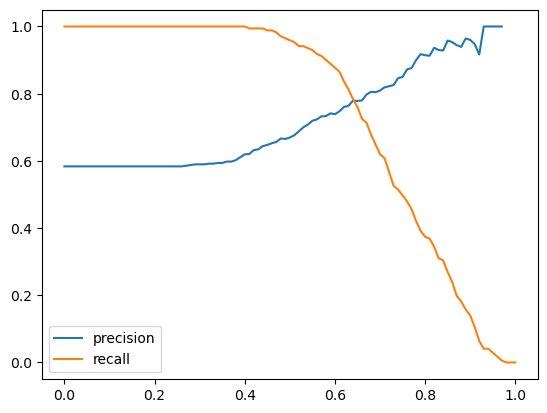

In [153]:
import matplotlib.pyplot as plt

actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    scores.append((t, tp, fp, fn, tn))
    #print(t,tp,tn,fp,fn)

columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['p'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['r'] = df_scores.tp / (df_scores.tp + df_scores.fn)

plt.plot(df_scores.threshold, df_scores['p'], label='precision')
plt.plot(df_scores.threshold, df_scores['r'], label='recall')
plt.legend()

In [154]:
# Question 4: F1 score

In [155]:
df_scores['f1'] = 2 * df_scores['p'] * df_scores['r'] / (df_scores['p'] + df_scores['r'])
df_scores.sort_values(by='f1', ascending=False)

,threshold,tp,fp,fn,tn,p,r,f1
57,0.57,156,57,15,65,0.732394,0.912281,0.812500
55,0.55,159,62,12,60,0.719457,0.929825,0.811224
56,0.56,157,60,14,62,0.723502,0.918129,0.809278
59,0.59,152,53,19,69,0.741463,0.888889,0.808511
58,0.58,154,56,17,66,0.733333,0.900585,0.808399
...,...,...,...,...,...,...,...,...
96,0.96,3,0,168,122,1.000000,0.017544,0.034483
97,0.97,1,0,170,122,1.000000,0.005848,0.011628
98,0.98,0,0,171,122,NaN,0.000000,NaN
99,0.99,0,0,171,122,NaN,0.000000,NaN


In [156]:
# maximal F1 at threshold of 0.57

In [157]:
# Question 5: 5-Fold CV

In [158]:
from sklearn.model_selection import KFold

def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

kfold = KFold(n_splits=5, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_train_full):
    df_train = df_train_full.iloc[train_idx]
    df_val = df_train_full.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train, y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.822 +- 0.036


In [159]:
# Question 6: Hyperparameter Tuning

In [161]:
kfold = KFold(n_splits=5, shuffle=True, random_state=1)

#scores = []

for C in [0.000001, 0.001, 1]:
    scores = []
    for train_idx, val_idx in kfold.split(df_train_full):
        df_train = df_train_full.iloc[train_idx]
        df_val = df_train_full.iloc[val_idx]
    
        y_train = df_train.converted.values
        y_val = df_val.converted.values
    
        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    
    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

C=1e-06 0.560 +- 0.024
C=0.001 0.867 +- 0.029
C=1 0.822 +- 0.036
